# 🔬 EPFL Mitochondria Bioimage Segmentation with U-Net (PyTorch)
## 🎓 Deep Learning Applied to Bioimage Analysis (DLBA - PUCP)
**Instructor:** Gabriel Jiménez  
**Hardware:** Google Colab (GPU Acceleration: NVIDIA T4 / A100)  

---

### 📌 Contexto del Proyecto y Desafíos Bioimagen
1. **Dataset:** **EPFL Mitochondria** (Microscopía Electrónica de Transmisión - TEM, Hipocampo CA1 de ratón).
2. **Estructura Volumétrica:** Stack 3D de 165 cortes de $768 \times 1024$ píxeles (8-bit escala de grises, resolución $\sim 5\times 5\times 5\text{ nm/vóxel}$).
3. **Desafío Clave:** Fuerte desbalance de clases (las mitocondrias representan solo el **5.63%** del volumen; ratio **16.8:1** frente al fondo celular).
4. **Estrategia Metodológica:**
   - **Partición Z-Stack (80% Train / 20% Val):** Previene la fuga de información (*data leakage*) entre cortes 3D continuos.
   - **Extracción de Parches 2D:** Sub-imágenes de $256 \times 256$ píxeles.
   - **Aumentación Síncrona:** Rotaciones espaciales (90°, 180°, 270°) y reflexiones simétricas.
   - **Pérdida Compuesta:** $\mathcal{L}_{\text{BCE+Dice}} = 0.5\cdot \mathcal{L}_{\text{BCE}} + 1.0\cdot \mathcal{L}_{\text{Dice}}$ para optimizar directamente la morfología y mitigar el desbalance.
   - **Métricas Objetivo:** Coeficiente de Similitud Dice (DSC) e Intersección sobre Unión (IoU / Jaccard).

Python: 3.12.13
PyTorch: 2.11.0+cu128
GPU: Tesla T4
Descargando training.tif...
Listo
Descargando training_groundtruth.tif...
Listo
Volumen: (165, 768, 1024)
Mitocondrias: 5.63% del volumen (ratio fondo:mito = 16.8:1)
Train: 400 parches/epoca | Val: 100 parches


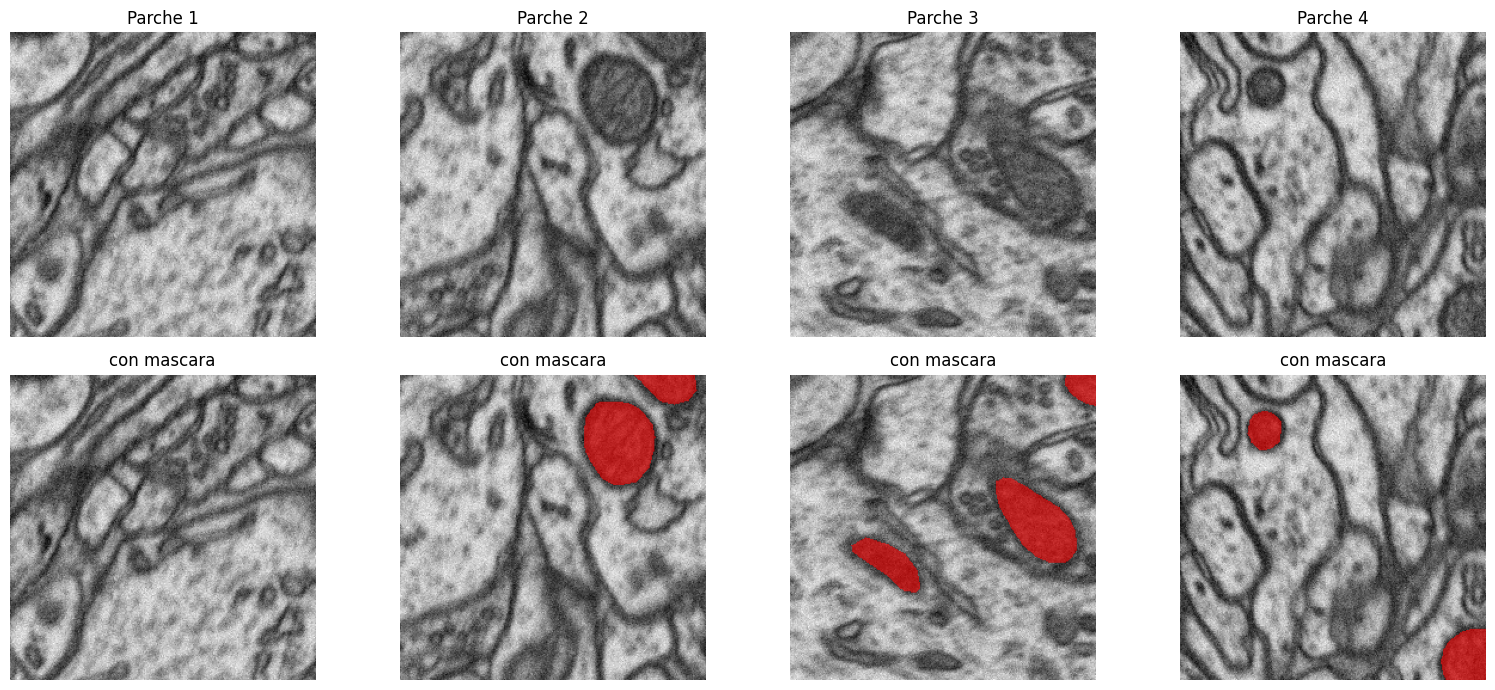

Parametros: 7,762,465
Entrenando hasta 100 epocas (early stopping con patience=15) en cuda...
Epoca [  1/100] Train Loss: 0.6354 Dice: 0.5187 | Val Loss: 1.1326 Dice: 0.3195 IoU: 0.1914
Epoca [  5/100] Train Loss: 0.3033 Dice: 0.8398 | Val Loss: 0.3972 Dice: 0.6940 IoU: 0.5616
Epoca [ 10/100] Train Loss: 0.1330 Dice: 0.8953 | Val Loss: 0.2128 Dice: 0.8163 IoU: 0.6925
Epoca [ 15/100] Train Loss: 0.0912 Dice: 0.9143 | Val Loss: 0.1155 Dice: 0.8967 IoU: 0.8155
Epoca [ 20/100] Train Loss: 0.0776 Dice: 0.9198 | Val Loss: 0.0729 Dice: 0.9260 IoU: 0.8625
Epoca [ 25/100] Train Loss: 0.0770 Dice: 0.9164 | Val Loss: 0.1011 Dice: 0.8919 IoU: 0.8086
Epoca [ 30/100] Train Loss: 0.0671 Dice: 0.9267 | Val Loss: 0.0991 Dice: 0.8720 IoU: 0.7791
Epoca [ 35/100] Train Loss: 0.0643 Dice: 0.9283 | Val Loss: 0.0777 Dice: 0.9131 IoU: 0.8405
Epoca [ 40/100] Train Loss: 0.0646 Dice: 0.9285 | Val Loss: 0.0707 Dice: 0.9180 IoU: 0.8495

Early stopping en epoca 44: Val Dice no mejora hace 15 epocas seguidas

Entre

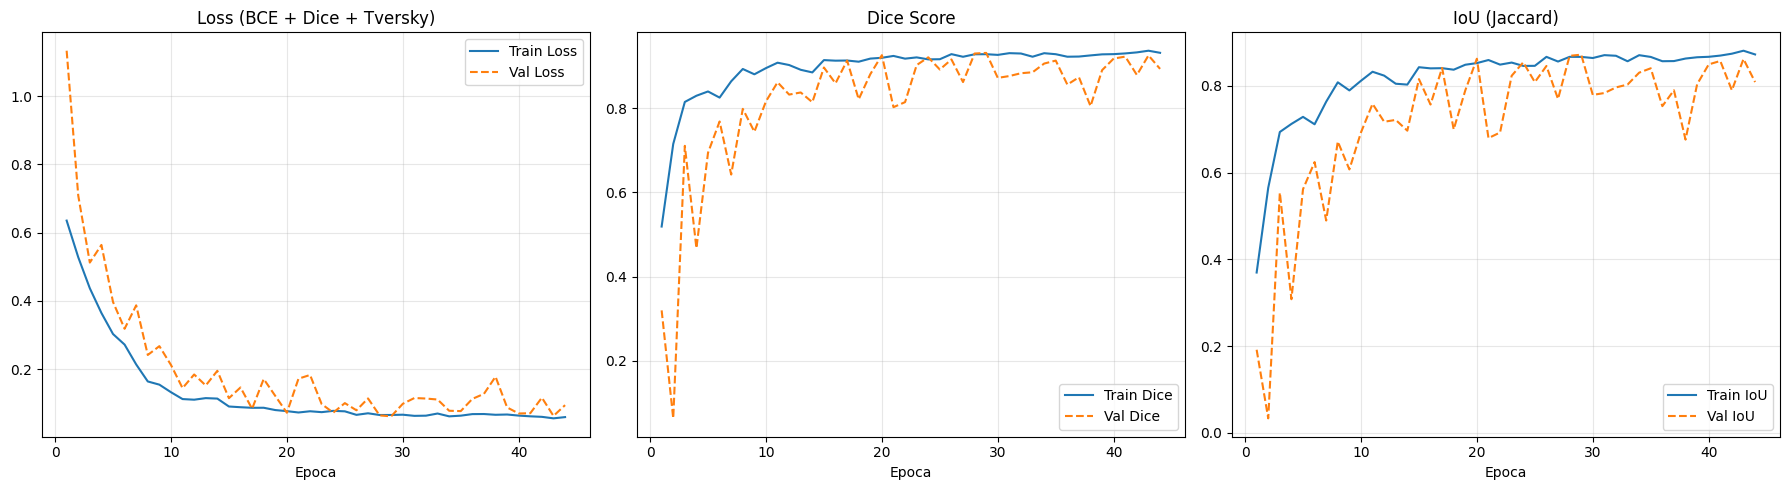

Checkpoint cargado (epoca 29, Val Dice: 0.9314)


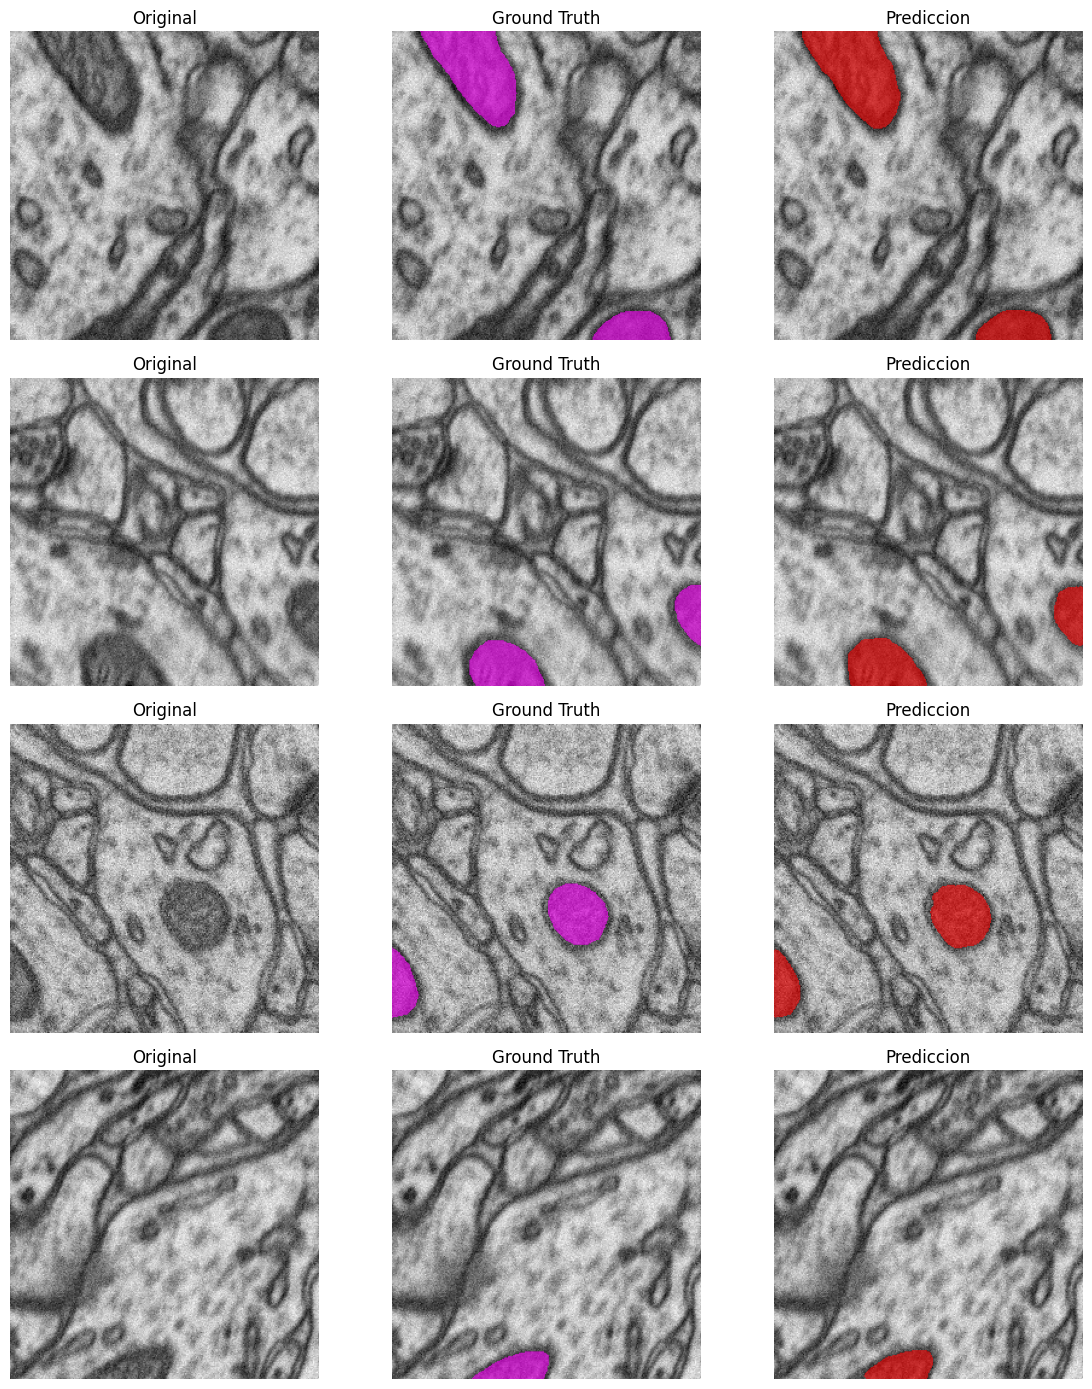

In [1]:
# ---- celda: chequeo de GPU ----
import torch, sys

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU, corriendo en CPU (en Runtime > Change runtime type, selecciona T4 GPU)")


# ---- celda: instalar dependencias ----
!pip install -q tifffile


# ---- celda: descargar el dataset EPFL Mitochondria ----
import urllib.request, os
import tifffile
import numpy as np

DATA_DIR = "data/raw/epfl_mitochondria"
os.makedirs(DATA_DIR, exist_ok=True)

EPFL_BASE_URL = "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/"
FILES = {"training.tif": "training.tif", "training_groundtruth.tif": "training_groundtruth.tif"}

def download_file(url, dest):
    if os.path.exists(dest):
        print(f"{os.path.basename(dest)} ya esta descargado")
        return
    print(f"Descargando {os.path.basename(dest)}...")
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r, open(dest, 'wb') as f:
        f.write(r.read())
    print("Listo")

for fname in FILES.values():
    download_file(EPFL_BASE_URL + fname, os.path.join(DATA_DIR, fname))

image_volume = tifffile.imread(os.path.join(DATA_DIR, "training.tif"))
mask_volume = tifffile.imread(os.path.join(DATA_DIR, "training_groundtruth.tif"))

total_voxels = mask_volume.size
mito_voxels = int((mask_volume > 0).sum())
mito_pct = mito_voxels / total_voxels * 100
print(f"Volumen: {image_volume.shape}")
print(f"Mitocondrias: {mito_pct:.2f}% del volumen (ratio fondo:mito = {(100-mito_pct)/mito_pct:.1f}:1)")


# ---- celda: dataset y dataloaders ----
import random
from typing import Tuple
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class MitochondriaPatchDataset(Dataset):
    """Extrae parches 2D de 256x256 de un subconjunto de cortes Z."""
    def __init__(self, images_volume, masks_volume, slice_indices,
                 patch_size=256, samples_per_epoch=400, transform=True):
        self.patch_size = patch_size
        self.transform = transform
        self.samples_per_epoch = samples_per_epoch
        self.images = images_volume[slice_indices]
        self.masks = masks_volume[slice_indices]
        self.num_slices, self.height, self.width = self.images.shape

    def __len__(self):
        return self.samples_per_epoch

    def _sync_transform(self, img, mask):
        if random.random() > 0.5:
            img = np.fliplr(img); mask = np.fliplr(mask)
        if random.random() > 0.5:
            img = np.flipud(img); mask = np.flipud(mask)
        if random.random() > 0.5:
            k = random.choice([1, 2, 3])
            img = np.rot90(img, k, axes=(0, 1))
            mask = np.rot90(mask, k, axes=(0, 1))
        return img.copy(), mask.copy()

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        s = random.randint(0, self.num_slices - 1)
        y0 = random.randint(0, self.height - self.patch_size)
        x0 = random.randint(0, self.width - self.patch_size)

        img_patch = self.images[s, y0:y0+self.patch_size, x0:x0+self.patch_size]
        mask_patch = self.masks[s, y0:y0+self.patch_size, x0:x0+self.patch_size]

        img_np = img_patch.astype(np.float32) / 255.0
        mask_np = (mask_patch.astype(np.float32) > 0).astype(np.float32)

        if self.transform:
            img_np, mask_np = self._sync_transform(img_np, mask_np)

        return (torch.from_numpy(img_np).unsqueeze(0).float(),
                torch.from_numpy(mask_np).unsqueeze(0).float())


total_slices = image_volume.shape[0]
train_slices = list(range(0, int(total_slices * 0.8)))
val_slices = list(range(int(total_slices * 0.8), total_slices))

train_dataset = MitochondriaPatchDataset(image_volume, mask_volume, train_slices, samples_per_epoch=400, transform=True)
val_dataset = MitochondriaPatchDataset(image_volume, mask_volume, val_slices, samples_per_epoch=100, transform=False)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} parches/epoca | Val: {len(val_dataset)} parches")


# ---- celda: ver un batch de ejemplo ----
sample_imgs, sample_masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(4):
    img_np = sample_imgs[i, 0].numpy()
    mask_np = sample_masks[i, 0].numpy()
    axes[0, i].imshow(img_np, cmap='gray')
    axes[0, i].set_title(f"Parche {i+1}")
    axes[0, i].axis('off')
    axes[1, i].imshow(img_np, cmap='gray')
    axes[1, i].imshow(np.ma.masked_where(mask_np < 0.5, mask_np), cmap='autumn', alpha=0.6)
    axes[1, i].set_title("con mascara")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


# ---- celda: arquitectura U-Net ----
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        if diff_y != 0 or diff_x != 0:
            x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_filters)
        self.down1 = DownBlock(base_filters, base_filters * 2)
        self.down2 = DownBlock(base_filters * 2, base_filters * 4)
        self.down3 = DownBlock(base_filters * 4, base_filters * 8)
        self.down4 = DownBlock(base_filters * 8, base_filters * 16)
        self.up1 = UpBlock(base_filters * 16, base_filters * 8)
        self.up2 = UpBlock(base_filters * 8, base_filters * 4)
        self.up3 = UpBlock(base_filters * 4, base_filters * 2)
        self.up4 = UpBlock(base_filters * 2, base_filters)
        self.outc = nn.Conv2d(base_filters, out_channels, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

model = UNet(in_channels=1, out_channels=1, base_filters=32).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametros: {total_params:,}")


# ---- celda: losses (BCE + Dice + Tversky) y metricas ----
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p, t = probs.view(-1), targets.view(-1)
        inter = (p * t).sum()
        dice = (2*inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return 1 - dice

class TverskyLoss(nn.Module):
    """alpha pesa mas los falsos negativos que beta a los falsos positivos.
    Como las mitocondrias son ~5.6% del volumen, conviene castigar mas
    perder mitocondrias (FN) que marcar de mas (FP)."""
    def __init__(self, alpha=0.7, beta=0.3, smooth=1.0):
        super().__init__()
        self.alpha, self.beta, self.smooth = alpha, beta, smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p, t = probs.view(-1), targets.view(-1)
        tp = (p * t).sum()
        fp = (p * (1 - t)).sum()
        fn = ((1 - p) * t).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha*fn + self.beta*fp + self.smooth)
        return 1 - tversky

class CombinedLoss(nn.Module):
    def __init__(self, bce_w=0.3, dice_w=0.35, tversky_w=0.35):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.tversky = TverskyLoss()
        self.bce_w, self.dice_w, self.tversky_w = bce_w, dice_w, tversky_w
    def forward(self, logits, targets):
        return (self.bce_w * self.bce(logits, targets)
                + self.dice_w * self.dice(logits, targets)
                + self.tversky_w * self.tversky(logits, targets))

def compute_metrics(logits, targets, threshold=0.5, eps=1e-7):
    with torch.no_grad():
        preds = (torch.sigmoid(logits) >= threshold).float()
        p, g = preds.view(-1), targets.view(-1)
        tp = (p * g).sum().item()
        fp = (p * (1 - g)).sum().item()
        fn = ((1 - p) * g).sum().item()
        dice = (2*tp + eps) / (2*tp + fp + fn + eps)
        iou = (tp + eps) / (tp + fp + fn + eps)
    return {"dice": dice, "iou": iou}


# ---- celda: entrenamiento con early stopping ----
import time

MAX_EPOCHS = 100
PATIENCE = 15       # si el val dice no mejora en 15 epocas seguidas, se corta
LEARNING_RATE = 1e-3
CHECKPOINT_PATH = "best_mitochondria_unet_colab.pth"

criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": [], "train_iou": [], "val_iou": []}
best_val_dice = -1.0
epochs_no_improve = 0
start_time = time.time()

print(f"Entrenando hasta {MAX_EPOCHS} epocas (early stopping con patience={PATIENCE}) en {device}...")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss, train_dice, train_iou = 0.0, 0.0, 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        m = compute_metrics(logits, masks)
        train_dice += m["dice"]; train_iou += m["iou"]

    model.eval()
    val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)
            val_loss += loss.item()
            m = compute_metrics(logits, masks)
            val_dice += m["dice"]; val_iou += m["iou"]

    ep_train_loss = train_loss / len(train_loader)
    ep_val_loss = val_loss / len(val_loader)
    ep_train_dice = train_dice / len(train_loader)
    ep_val_dice = val_dice / len(val_loader)
    ep_train_iou = train_iou / len(train_loader)
    ep_val_iou = val_iou / len(val_loader)

    history["train_loss"].append(ep_train_loss)
    history["val_loss"].append(ep_val_loss)
    history["train_dice"].append(ep_train_dice)
    history["val_dice"].append(ep_val_dice)
    history["train_iou"].append(ep_train_iou)
    history["val_iou"].append(ep_val_iou)

    if ep_val_dice > best_val_dice + 1e-4:
        best_val_dice = ep_val_dice
        epochs_no_improve = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_dice': best_val_dice, 'val_iou': ep_val_iou}, CHECKPOINT_PATH)
    else:
        epochs_no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoca [{epoch:3d}/{MAX_EPOCHS}] Train Loss: {ep_train_loss:.4f} Dice: {ep_train_dice:.4f} | "
              f"Val Loss: {ep_val_loss:.4f} Dice: {ep_val_dice:.4f} IoU: {ep_val_iou:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping en epoca {epoch}: Val Dice no mejora hace {PATIENCE} epocas seguidas")
        break

total_min = (time.time() - start_time) / 60.0
print(f"\nEntrenamiento terminado en {total_min:.2f} minutos. Mejor Val Dice: {best_val_dice:.4f}")


# ---- celda: curvas de entrenamiento ----
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label='Train Loss')
axes[0].plot(epochs_range, history["val_loss"], label='Val Loss', linestyle='--')
axes[0].set_title("Loss (BCE + Dice + Tversky)"); axes[0].set_xlabel("Epoca"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_dice"], label='Train Dice')
axes[1].plot(epochs_range, history["val_dice"], label='Val Dice', linestyle='--')
axes[1].set_title("Dice Score"); axes[1].set_xlabel("Epoca"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["train_iou"], label='Train IoU')
axes[2].plot(epochs_range, history["val_iou"], label='Val IoU', linestyle='--')
axes[2].set_title("IoU (Jaccard)"); axes[2].set_xlabel("Epoca"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mitochondria_training_curves.png", dpi=200, bbox_inches='tight')
plt.show()


# ---- celda: resultados cualitativos ----
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Checkpoint cargado (epoca {checkpoint['epoch']}, Val Dice: {checkpoint['val_dice']:.4f})")

sample_indices = []
for idx in range(len(val_dataset)):
    _, mask_t = val_dataset[idx]
    if (mask_t > 0.5).sum() > 300:
        sample_indices.append(idx)
    if len(sample_indices) == 4:
        break

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
with torch.no_grad():
    for row, idx in enumerate(sample_indices):
        img_t, mask_t = val_dataset[idx]
        logits = model(img_t.unsqueeze(0).to(device))
        pred_bin = (torch.sigmoid(logits).squeeze().cpu().numpy() >= 0.5).astype(np.float32)
        img_np = img_t.squeeze().numpy()
        mask_np = mask_t.squeeze().numpy()

        axes[row, 0].imshow(img_np, cmap='gray'); axes[row, 0].set_title("Original"); axes[row, 0].axis('off')
        axes[row, 1].imshow(img_np, cmap='gray')
        axes[row, 1].imshow(np.ma.masked_where(mask_np < 0.5, mask_np), cmap='spring', alpha=0.6)
        axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis('off')
        axes[row, 2].imshow(img_np, cmap='gray')
        axes[row, 2].imshow(np.ma.masked_where(pred_bin < 0.5, pred_bin), cmap='autumn', alpha=0.6)
        axes[row, 2].set_title("Prediccion"); axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig("mitochondria_segmentation_results.png", dpi=200, bbox_inches='tight')
plt.show()